### Метод Ньютона

Задание

1. ответить на все вопросы в скрипте
2. изменить код метода Ньютона так, чтобы он смог разрешать все проблемные случаи, возникающие в скрипте, продемонстрировать это, объяснить почему модификация решает проблему. Проблемы - нулевая производная, кратные корни, биения. Для кратных корней надо так модифицировать метод, чтобы порядок оставался вторым и продемонстрировать это.

ВАЖНО! 
1. Модифицированный метод Ньютона должен получаться путем добавления новых строчек в simple_newton, а не переписыванием его с нуля. Новые строчки надо прокомментировать, зачем они были добавлены.
2. Для каждого нелинейного, где есть указанные проблемы, надо привести демонстрацию решения вашим методом. Без этой демонстрации считается, что обработчик соответствующей проблемы не реализован и не оценивается.

In [225]:
# простая реализация Метода Ньютона
%matplotlib inline 
import matplotlib.pyplot as plt
import numpy as np

def simple_newton(func, dfunc, x, tol = 1e-12):
    sol = 0
    iteration = 0
    dxs = []
    for i in range(30):
        iteration += 1
        dx = -func(x)/dfunc(x)
        dxs.append(abs(dx))
        x = x + dx
        #print(x)
        if abs(dx) < tol:
            sol = x
            return [sol, iteration, dxs]
    sol = float('nan')
    print('More then 30 iterations!')
    return [sol, iteration]

In [226]:
# модифицированная реализация Метода Ньютона

def complex_newton(func, dfunc, x, tol = 1e-12, m=1):
    sol = 0
    iteration = 0
    dxs = []
    for i in range(30):
        iteration += 1

        # Если происходят биения уменьшаем дельту
        if (len(dxs)>=2):
            if (dxs[-1]>=dxs[-2]):
                #Домножаем на m - кратность корня
                dx = -0.5*m*func(x)/dfunc(x) if abs(dfunc(x)) !=0 else -0.5*m*func(x)*1e-2
            else:
                # В случае если производная равна 0, вместно неё умножаем на константу
                dx = -m*func(x)/dfunc(x) if abs(dfunc(x)) !=0 else -m*func(x)*1e-2
        else:
            dx = -m*func(x)/dfunc(x) if abs(dfunc(x)) !=0 else -m*func(x)*1e-2

        dxs.append(abs(dx))
        x = x + dx
        #print(x)
        if abs(dx) < tol:
            sol = x
            return [sol, iteration, dxs]
    sol = float('nan')
    print('More then 30 iterations!')
    return [sol, iteration, dxs]
    

#### Нелинейное уравнение 1

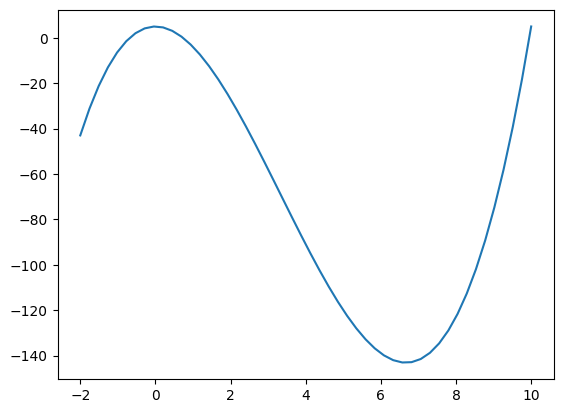

In [227]:
x = np.linspace(-2,10)
func0 = lambda x: x**3 - 10*x**2 + 5
dfunc0 = lambda x: 3*x**2 - 20*x
y = func0(x)
plt.plot(x, y)

1. Объяснить, почему различаются результаты в случае 1 и 2
2. Объяснить, что происходит в случае 3
3. Построить график порядка сходимости от номера итерации. Объяснить результат

In [228]:
#data = simple_newton(func0, dfunc0, 8) # случай 1
#data = simple_newton(func0, dfunc0, 0.7) # случай 2
data = simple_newton(func0, dfunc0, 0.0) # случай 3
print('sol = ', data[0])
print('iter = ', data[1])

ZeroDivisionError: float division by zero

1. В случаях 1 и 2 производные "направляют" последовательности в однинаковы направления, но натыкаются они на 2 разные области сходимости.
2. Производная равна 0.
3. Выразим порядок:
$$q_n=\frac{\ln(\frac{x^n-x^*}{C})}{\ln(x^{n-1}-x^*)}$$

sol =  -0.6840945657036894
iter =  15


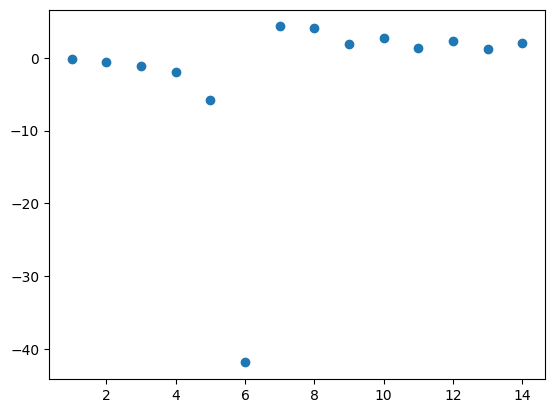

In [232]:
#data = complex_newton(func0, dfunc0, 8) # случай 1
#data = complex_newton(func0, dfunc0, 0.7) # случай 2
data = complex_newton(func0, dfunc0, 0.0) # случай 3
print('sol = ', data[0])
print('iter = ', data[1])

n = np.arange(1, data[1])
func0 = lambda x: x**3 - 10*x**2 + 5
q=[]
for i in n:
    q.append(np.log(abs(sum(data[2][-(data[1]-i):])/dfunc0(data[0])))/np.log(abs(sum(data[2][-(data[1]-i+1):]))))
plt.plot(n, q,'o')

#### Нелинейное уравнение 2

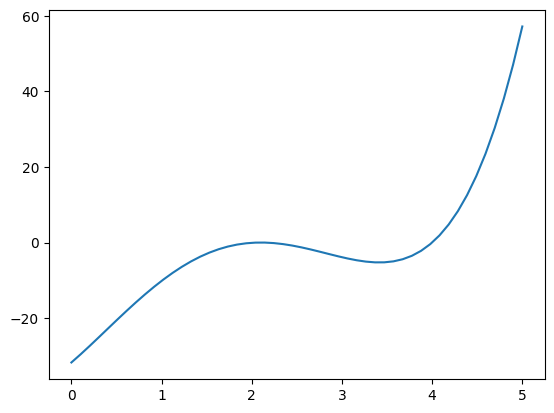

In [233]:
x = np.linspace(0,5)
func1 = lambda x: x**4 - 6.4*x**3 + 6.45*x**2 + 20.538*x - 31.752 
dfunc1 = lambda x: 4.0*x**3 - 19.2*x**2 + 12.9*x + 20.538
y = func1(x)
plt.plot(x, y)

1. Построить график порядка сходимости от номера итерации. Объяснить результат

In [234]:
data = simple_newton(func1, dfunc1, 2.0)
print('sol = ', data[0])
print('iter = ', data[1])

sol =  2.0999999786199406
iter =  23


/tmp/ipykernel_19528/764552251.py:4: RuntimeWarning: divide by zero encountered in log
  q.append(np.log(abs(sum(data[2][-(data[1]-i):])/dfunc1(data[0])))/np.log(abs(sum(data[2][-(data[1]-i+1):]))))


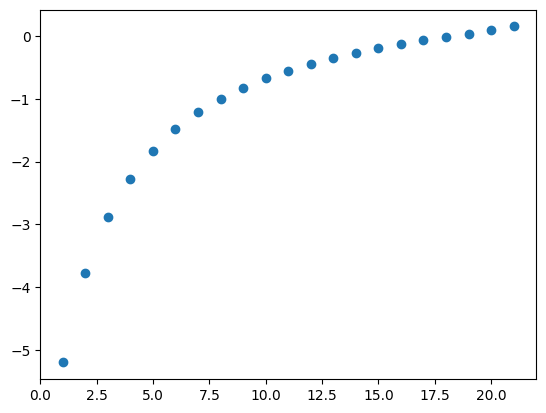

In [235]:
n = np.arange(1, data[1])
q=[]
for i in n:
    q.append(np.log(abs(sum(data[2][-(data[1]-i):])/dfunc1(data[0])))/np.log(abs(sum(data[2][-(data[1]-i+1):]))))
plt.plot(n, q, 'o')

sol =  2.1000000025011976
iter =  7


/tmp/ipykernel_19528/1917671213.py:9: RuntimeWarning: divide by zero encountered in log
  q.append(np.log(abs(sum(data[2][-(data[1]-i):])/dfunc1(data[0])))/np.log(abs(sum(data[2][-(data[1]-i+1):]))))


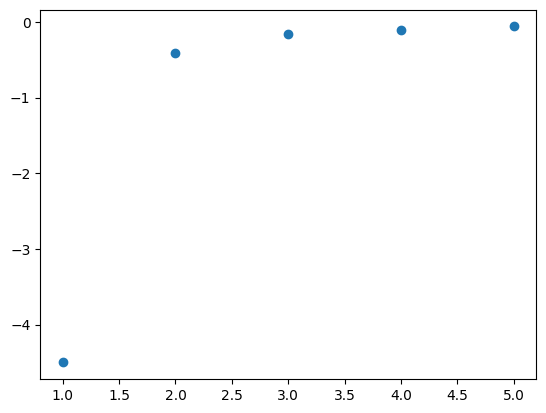

In [236]:
data = complex_newton(func1, dfunc1, 2.0, m=2)
print('sol = ', data[0])
print('iter = ', data[1])

#Строим зависимоть порядка сходимости от номера итерации
n = np.arange(1, data[1])
q=[]
for i in n:
    q.append(np.log(abs(sum(data[2][-(data[1]-i):])/dfunc1(data[0])))/np.log(abs(sum(data[2][-(data[1]-i+1):]))))
plt.plot(n, q, 'o')

#### Нелинейное уравнение 3

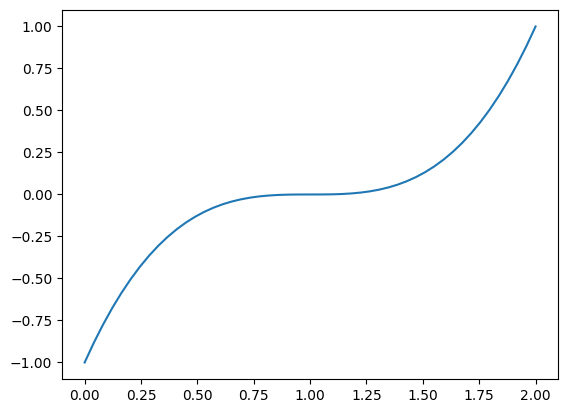

In [237]:
x = np.linspace(0,2)
func2 = lambda x: (x-1)**3
dfunc2 = lambda x: 3*(x-1)**2
y = func2(x)
plt.plot(x, y)

1. Подобрать начальное приближение и решить задачу

In [238]:
data = simple_newton(func2, dfunc2, 1.0000001)
print('sol = ', data[0])
print('iter = ', data[1])

sol =  1.0000000000017601
iter =  27


sol =  1.000000000000188
iter =  12


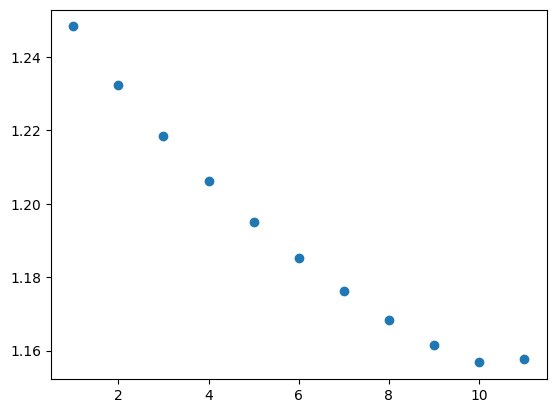

In [239]:
data = complex_newton(func2, dfunc2, 1.0000001, m=2)
print('sol = ', data[0])
print('iter = ', data[1])

#Строим зависимоть порядка сходимости от номера итерации
n = np.arange(1, data[1])
q=[]
for i in n:
    q.append(np.log(abs(sum(data[2][-(data[1]-i):])/dfunc1(data[0])))/np.log(abs(sum(data[2][-(data[1]-i+1):]))))
plt.plot(n, q, 'o')

#### Нелинейное уравнение 4

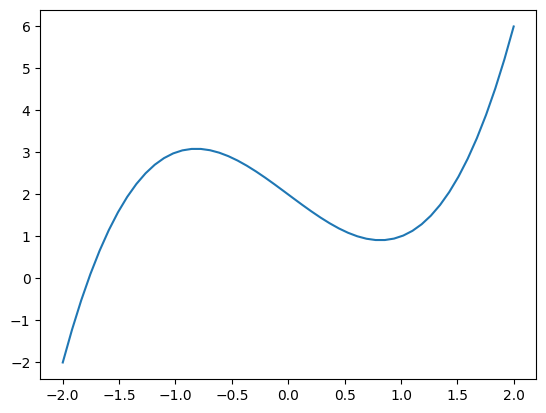

In [240]:
x = np.linspace(-2,2)
#x = np.linspace(-5,5)
func3 = lambda x: x**3 - 2*x + 2
dfunc3 = lambda x: 3*x**2 - 2
y = func3(x)
plt.plot(x, y)

1. Почему не находится решение во втором случае?

In [241]:
#data = simple_newton(func3, dfunc3, 0.5) # случай 1
data = simple_newton(func3, dfunc3, 0) # случай 2
print('sol = ', data[0])
print('iter = ', data[1])

More then 30 iterations!
sol =  nan
iter =  30


1. Потому что ряд "застревает" на экстремумах

In [244]:
#data = complex_newton(func3, dfunc3, 0.5) # случай 1
data = complex_newton(func3, dfunc3, 0) # случай 2
print('sol = ', data[0])
print('iter = ', data[1])

sol =  -1.7692923542386314
iter =  25
